In [1]:

import jax.numpy as jnp

import sys
sys.path.insert(1,'../scripts/')

import gzip
import pickle
import utils
import loader
import tqdm
%load_ext autoreload
%autoreload 2
import imp
imp.reload(loader)
import setup
import scipy.stats as sts
from matplotlib import pyplot as plt

import numpy as np
import seaborn as sns 
import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

In [ ]:
def get_corr_time(train_data_folds,test_data_folds,n_folds=100,w=10):

    all_corrs = np.zeros((n_folds,len(_ys[0])-w))*np.nan


    for fold in tqdm.trange(n_folds):
        
        train_fold, test_fold = train_data_folds[fold],test_data_folds[fold]
        ys_time,_ = zip(*train_fold)
        _,cs_time = zip(*test_fold)

        # fitler out sessions with too few neurons or trials
        min_neurons = 100
        min_trials = 20

        valid = [i for i in range(len(ys_time)) if np.array(_ys[i]).shape[-1] >= min_neurons and np.array(_ys[i]).shape[1] >= min_trials]
        ys_time = [ys_time[i] for i in valid]
        cs = [cs_time[i][0] for i in valid]

        S = len(ys_time)


        for t in range(len(ys_time[0])-w):

            # get best min_neurons and current time point +window
            all_sessions = []
            for session in range(S):
                ys_sess = ys_time[session][t:t+w,:].reshape(-1,ys_time[session].shape[-1])
                ys_sess = ys_sess[:,np.argsort(ys_sess.std(0))][:,:min_neurons]
                all_sessions.append(ys_sess)

            try:
                dist_neural = utils.dsd([
                    [all_sessions[i],all_sessions[j]]
                    for i in range(S) 
                    for j in range(S)]
                ).reshape(S,S)


                """dist_cc = np.zeros((S,S))
                for i in range(S):
                    for j in range(S):
                        dist_cc[i,j] = np.mean(np.abs(cs[i]- cs[j]))"""
                
                corr_matrix = np.corrcoef(cs)
                dist_cc = 1 - corr_matrix

                corr = sts.pearsonr(dist_neural[~jnp.eye(dist_neural.shape[0],dtype=bool)],
                        dist_cc[~jnp.eye(dist_cc.shape[0],dtype=bool)])[0]
                
            except Exception as e:

                print(t,fold,"linalg error/nan")
                continue
            
            all_corrs[fold,t]=corr

    return all_corrs


def process_and_correlate_fold(fold, w=10, s=1, r='all'):

    all_corrs = [] # to save the correlations for each time bin

    ys_time, cs_time, regions = fold['ys'], fold['cs_t'], fold['r']

    min_neurons = 100

    S = len(ys_time)

    mask = np.eye(S, dtype=bool)

    # Behavioral distance doesnt change across windows

    """dist_cc = np.zeros((S,S))
    for i in range(S):
        for j in range(S):
            dist_cc[i,j] = np.mean(np.abs(cs_time[i]- cs_time[j]))"""
    
                    
    corr_matrix = np.corrcoef(cs_time)
    dist_cc = 1 - corr_matrix

    # Adding some stride to speed up
    for t in range(0, len(ys_time[0])-w, s):  # Stride of s

        # get best min_neurons and current time point + window
        all_sessions = []
        for session in range(S):

            ys_session = ys_time[session][t:t+w,:] # (time window, cond, neurons)

            # Slide window and reshape to (time*cond, neurons)
            ys_sess = ys_session.reshape(-1,ys_session.shape[-1])

            # Gets the least variable neurons across conditions --> does it make sense?
            # Shouldnt we get the most variable ones?
            # I gess anyways you would need to get the same amount of neurons for all sessions to apply shape metrics
            ys_sess = ys_sess[:,np.argsort(ys_sess.std(0))][:,:min_neurons]

            all_sessions.append(ys_sess)

        try:
            dist_neural = utils.dsd([
                [all_sessions[i],all_sessions[j]]
                for i in range(S) 
                for j in range(S)]
            ).reshape(S,S)

            # Puting this inside or outside is the same since behavior is a subject property and not a time-varying one
            # I empirically checked
            """corr_matrix = np.corrcoef(cs_time)
            dist_cc = 1 - corr_matrix"""

            corr = sts.pearsonr(dist_neural[~mask], dist_cc[~mask])[0]

        except (np.linalg.LinAlgError, ValueError):
            print(t, " linear algebra error/nan")
            # Can occour when the optimization problem does not converge?
            all_corrs.append(np.nan)
            continue
        
        all_corrs.append(corr)

    return all_corrs


In [6]:
with open("prep_data/folds_index_stim.pkl","rb") as f:
    index = pickle.load(f)

with gzip.open(f"{index['files'][0]}", "rb") as g:
    fold = pickle.load(g)

In [50]:
print(len(fold['ys'])) # number of sessions
print(len(fold['ys'][0])) # number of time points
print(fold['ys'][0][0].shape) # shape of each time point (cond, neurons)

32
150
(9, 367)


In [55]:
yw=fold['ys'][0][0:10]
yw.reshape(-1,yw.shape[-1]).shape

(90, 367)

In [7]:
all_corrs_resp.shape

(25, 140)

In [9]:
# load data 

with open("prep_data/folds_index_response.pkl","rb") as f:
    index = pickle.load(f)

all_corrs_resp = []
for fold_path in tqdm.tqdm(index['files']):
    with gzip.open(f"{fold_path}", "rb") as g:
        fold = pickle.load(g)

        all_corrs = process_and_correlate_fold(fold)
        all_corrs_resp.append(all_corrs)

all_corrs_resp = np.array(all_corrs_resp)


  0%|          | 0/25 [00:00<?, ?it/s]

10  linear algebra error/nan


  4%|▍         | 1/25 [00:46<18:32, 46.35s/it]

58  linear algebra error/nan


 12%|█▏        | 3/25 [02:19<17:01, 46.44s/it]

...

 92%|█████████▏| 23/25 [20:34<02:11, 65.62s/it]

12  linear algebra error/nan
71  linear algebra error/nan


 96%|█████████▌| 24/25 [21:43<01:06, 66.44s/it]

8  linear algebra error/nan
81  linear algebra error/nan


100%|██████████| 25/25 [22:52<00:00, 54.89s/it]


In [ ]:
# load data 

with open("prep_data/folds_index_stim_DG.pkl","rb") as f:
    index = pickle.load(f)

all_corrs_stim = []
i=0
for fold_path in tqdm.tqdm(index['files']):
    #if i==2: break
    #i+=1

    with gzip.open(f"{fold_path}", "rb") as g:
        fold = pickle.load(g)

        all_corrs = process_and_correlate_fold(fold)
        all_corrs_stim.append(all_corrs)

#all_corrs_stim = get_corr_time(train_data_folds,test_data_folds,n_folds=25)
all_corrs_stim = np.array(all_corrs_stim)

    

  0%|          | 0/25 [00:00<?, ?it/s]

18  linear algebra error/nan
36  linear algebra error/nan
52  linear algebra error/nan
61  linear algebra error/nan
67  linear algebra error/nan
86  linear algebra error/nan
92  linear algebra error/nan
97  linear algebra error/nan
124  linear algebra error/nan


  4%|▍         | 1/25 [04:14<1:41:46, 254.45s/it]

14  linear algebra error/nan
43  linear algebra error/nan
44  linear algebra error/nan
67  linear algebra error/nan
75  linear algebra error/nan
79  linear algebra error/nan
124  linear algebra error/nan


  8%|▊         | 2/25 [07:42<1:27:00, 226.97s/it]

...

29  linear algebra error/nan
36  linear algebra error/nan
44  linear algebra error/nan
52  linear algebra error/nan
56  linear algebra error/nan
57  linear algebra error/nan
69  linear algebra error/nan
117  linear algebra error/nan
123  linear algebra error/nan
137  linear algebra error/nan


 76%|███████▌  | 19/25 [1:19:22<24:43, 247.23s/it]

3  linear algebra error/nan
8  linear algebra error/nan
15  linear algebra error/nan
32  linear algebra error/nan
45  linear algebra error/nan
51  linear algebra error/nan
99  linear algebra error/nan


 80%|████████  | 20/25 [1:23:41<20:53, 250.77s/it]

5  linear algebra error/nan
9  linear algebra error/nan


In [41]:
with(open("prep_data/25_avg_folds_stim_aligned.pkl","rb")) as f:
    import pickle
    params,_ys,train_data_folds,test_data_folds = pickle.load(f)

all_corrs_stim = get_corr_time(train_data_folds,test_data_folds,n_folds=25)



  4%|▍         | 1/25 [01:08<27:31, 68.83s/it]

7 1 linalg error/nan
23 1 linalg error/nan
27 1 linalg error/nan
61 1 linalg error/nan
72 1 linalg error/nan


  8%|▊         | 2/25 [02:20<27:03, 70.59s/it]

38 2 linalg error/nan
79 2 linalg error/nan


 12%|█▏        | 3/25 [03:31<26:00, 70.93s/it]

...

 92%|█████████▏| 23/25 [27:17<02:22, 71.20s/it]

59 23 linalg error/nan
132 23 linalg error/nan


 96%|█████████▌| 24/25 [28:28<01:10, 71.00s/it]

71 24 linalg error/nan


100%|██████████| 25/25 [29:39<00:00, 71.17s/it]


In [ ]:
print(len(ys)) # number of sessions/animals - it is taking just 2?
print(len(ys[0]))
print(len(ys[1]))
print(ys[0][1].shape)

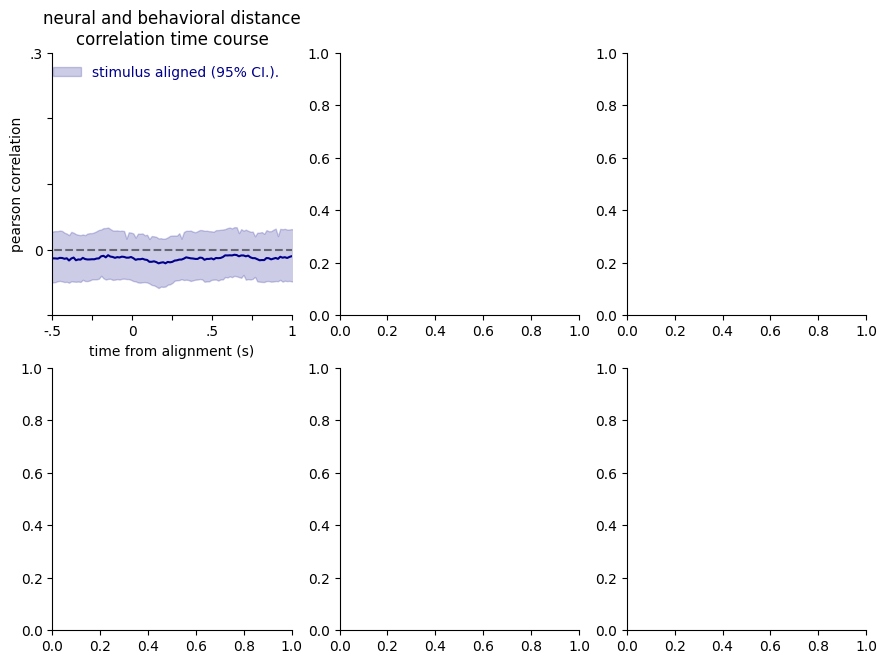

In [45]:
from matplotlib import pyplot as plt

sig_resp = (1-np.nanmean(all_corrs_stim>0,0))*2 <0.05

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))
axes = axes.flatten()

x_time = np.linspace(-1,1,len(all_corrs_stim[0]))
w=10
x_time += np.diff(x_time)[0]*w 


axes[0].plot(x_time,np.nanmean(all_corrs_stim,0),color="darkblue")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs_stim.T],[np.nanpercentile(a,97.5) for a in all_corrs_stim.T],color='darkblue',alpha=0.2,label='stimulus aligned (95% CI.).')

axes[0].plot(x_time[sig_resp],np.ones_like(x_time[sig_resp])*0.275,'|',color='darkblue')

axes[0].plot(x_time,np.zeros_like(x_time),'--',color='k',alpha=0.5)
axes[0].set_xlabel('time from alignment (s)')
axes[0].set_ylabel('pearson correlation')
axes[0].set_title('neural and behavioral distance\ncorrelation time course')
axes[0].legend()
axes[0].set_ylim(-0.1,0.3)
axes[0].set_xlim(-0.5,1)
axes[0].set_xlim(-0.5,1)
axes[0].set_ylim(-0.1,0.3)
axes[0].set_yticks([-0.1,0,0.1,0.2,0.3],['',0,'','','.3'])
axes[0].set_xticks([-0.5,-0.25,0,0.25,0.5,0.75,1],['-.5','','0','','.5','','1'])
axes[0].legend(frameon=False)
# change font color of legend
leg = axes[0].get_legend()
ltext  = leg.get_texts()

#plt.setp(ltext[1], color='darkred')
plt.setp(ltext[0], color='darkblue')
sns.despine()
#fig.tight_layout()


In [43]:
len(all_corrs_stim[6])

14

In [65]:
# If all lists should have same length, pad them first
all_corrs_stim_mean= np.array([np.array(x) for x in all_corrs_stim if len(x)==14]).mean(0)

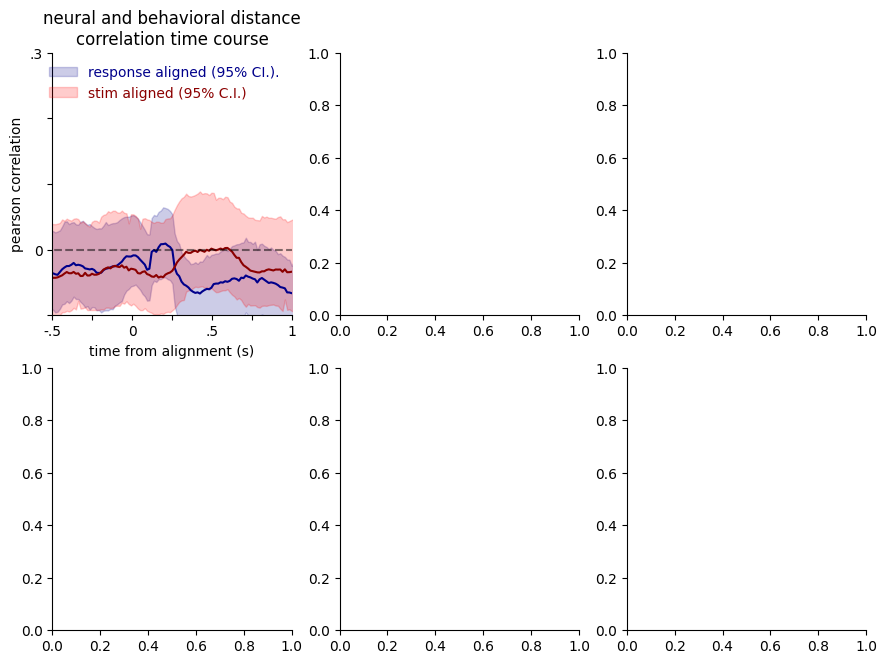

In [10]:
from matplotlib import pyplot as plt

sig_stim = (1-np.mean(all_corrs_stim>0,0))*2 <0.05
sig_resp = (1-np.mean(all_corrs_resp>0,0))*2 <0.05
sig_stim_resp = (1-np.mean(all_corrs_stim<np.mean(all_corrs_resp,0),0))*2 <0.05

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))
axes = axes.flatten()

x_time = np.linspace(-1,1,len(all_corrs_stim[0]))
w=10
x_time += np.diff(x_time)[0]*w


axes[0].plot(x_time,np.nanmean(all_corrs_resp,0),color="darkblue")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs_resp.T],[np.nanpercentile(a,97.5) for a in all_corrs_resp.T],color='darkblue',alpha=0.2,label='response aligned (95% CI.).')


axes[0].plot(x_time,np.nanmean(all_corrs_stim,0),color="darkred")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs_stim.T],[np.nanpercentile(a,97.5) for a in all_corrs_stim.T],color='r',alpha=0.2,label='stim aligned (95% C.I.)')

axes[0].plot(x_time[sig_stim],np.ones_like(x_time[sig_stim])*0.29,'|',color='darkred')
axes[0].plot(x_time[sig_resp],np.ones_like(x_time[sig_resp])*0.275,'|',color='darkblue')
axes[0].plot(x_time[sig_stim_resp],np.ones_like(x_time[sig_stim_resp])*0.26,'|',color='k')

axes[0].plot(x_time,np.zeros_like(x_time),'--',color='k',alpha=0.5)
axes[0].set_xlabel('time from alignment (s)')
axes[0].set_ylabel('pearson correlation')
axes[0].set_title('neural and behavioral distance\ncorrelation time course')
axes[0].legend()
axes[0].set_xlim(-0.5,1)
axes[0].set_ylim(-0.1,0.3)
axes[0].set_yticks([-0.1,0,0.1,0.2,0.3],['',0,'','','.3'])
axes[0].set_xticks([-0.5,-0.25,0,0.25,0.5,0.75,1],['-.5','','0','','.5','','1'])
axes[0].legend(frameon=False)
# change font color of legend
leg = axes[0].get_legend()
ltext  = leg.get_texts()

plt.setp(ltext[1], color='darkred')
plt.setp(ltext[0], color='darkblue')
sns.despine()
#fig.tight_layout()

#plt.savefig('../results/neural_behavioral_correlation_time_course.svg',dpi=300)